In [5]:
import os
import json
import pandas as pd

In [3]:
CKD_dataset_path = os.path.join("..","data","therapeutic_target_task", "EFO_0003884")
evidence_df = pd.read_csv(os.path.join(CKD_dataset_path, "disease_drug_evidence_EFO_0003884.csv"), sep="\t")
evidence_df.head()

,diseaseFromSourceMappedId,diseaseId,targetId,targetFromSourceId,clinicalPhase,clinicalStatus,drugId,targetId_genename
0,EFO_0003884,EFO_0003884,ENSG00000004779,O14561,3.0,"Active, not recruiting",DB00331,NDUFAB1
1,EFO_0003884,EFO_0003884,ENSG00000004779,O14561,2.0,Completed,DB00331,NDUFAB1
2,EFO_0003884,EFO_0003884,ENSG00000004779,O14561,3.0,"Active, not recruiting",CHEMBL1703,NDUFAB1
3,EFO_0003884,EFO_0003884,ENSG00000006071,Q09428,3.0,Completed,DB01067,ABCC8
4,EFO_0000401,EFO_0000401,ENSG00000012504,Q96RI1,2.0,Completed,DB16255,NR1H4


In [10]:
with open(os.path.join(CKD_dataset_path, "positive_proteins_EFO_0003884.json"),"r") as f:
    positive_labels = json.load(f)

with open(os.path.join(CKD_dataset_path, "negative_proteins_EFO_0003884.json"),"r") as f:
    negative_labels = json.load(f)

In [11]:
label_desc = {
    "Cell type": [],
    "Positive count": [],
    "Negative count": []
}

for cell_type, positive_proteins in positive_labels.items():
    negative_proteins = negative_labels.get(cell_type, [])
    label_desc["Cell type"].append(cell_type)
    label_desc["Positive count"].append(len(positive_proteins))
    label_desc["Negative count"].append(len(negative_proteins))

label_df = pd.DataFrame(label_desc)
label_df.head()

,Cell type,Positive count,Negative count
0,plasmablast,50,299
1,secretory_cell,56,365
2,sperm,50,287
3,basal_cell,52,370
4,granulocyte,44,345


In [18]:
label_df["Total target proteins"] = label_df["Positive count"] + label_df["Negative count"]
#positive fraction
label_df["Positive fraction"] = round(label_df["Positive count"] / label_df["Total target proteins"], 2)
#negative fraction
label_df["Negative fraction"] = round(label_df["Negative count"] / label_df["Total target proteins"], 2)

Total cell types: 156


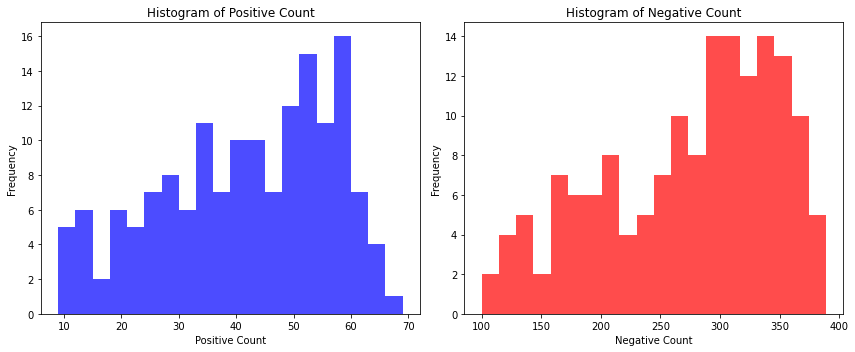

In [13]:
print("Total cell types:",label_df["Cell type"].nunique())
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram for Positive count
axes[0].hist(label_df["Positive count"], bins=20, color='blue', alpha=0.7)
axes[0].set_title("Histogram of Positive Count")
axes[0].set_xlabel("Positive Count")
axes[0].set_ylabel("Frequency")

# Histogram for Negative count
axes[1].hist(label_df["Negative count"], bins=20, color='red', alpha=0.7)
axes[1].set_title("Histogram of Negative Count")
axes[1].set_xlabel("Negative Count")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [16]:
print("These are the less likely cell types that could be involved in this disease")
print(label_df.sort_values(by="Positive count", ascending=True).head(10))

print("These are the most likely cell types that could be involved in this disease")
print(label_df.sort_values(by="Positive count", ascending=False).head(10))

These are the less likely cell types that could be involved in this disease
                                             Cell type  Positive count  \
59   naive_thymus-derived_cd4-positive,_alpha-beta_...               9   
111  cd8-positive,_alpha-beta_cytokine_secreting_ef...               9   
92                                              b_cell              10   
53                                             nk_cell              10   
50                                       memory_b_cell              11   
66                                    type_i_nk_t_cell              12   
130             cd4-positive,_alpha-beta_memory_t_cell              13   
5                                        dn3_thymocyte              13   
85                        immature_natural_killer_cell              14   
121                             non-classical_monocyte              14   

     Negative count  
59              118  
111             159  
92              114  
53              164  

In [17]:
print("These are the less likely cell types that could be involved in this disease")
print(label_df.sort_values(by="Negative count", ascending=False).head(10))

print("These are the most likely cell types that could be involved in this disease")
print(label_df.sort_values(by="Negative count", ascending=True).head(10))

These are the less likely cell types that could be involved in this disease
                                         Cell type  Positive count  \
82                              type_ii_pneumocyte              59   
71   intestinal_crypt_stem_cell_of_small_intestine              58   
114           cd1c-positive_myeloid_dendritic_cell              44   
122                                     hepatocyte              62   
140                              radial_glial_cell              54   
155                                     macrophage              56   
79           cd141-positive_myeloid_dendritic_cell              51   
73                                    myeloid_cell              47   
22                      intrahepatic_cholangiocyte              57   
3                                       basal_cell              52   

     Negative count  
82              389  
71              387  
114             386  
122             384  
140             383  
155             373  

In [19]:
label_df.head()

,Cell type,Positive count,Negative count,Total target proteins,Positive fraction,Negative fraction
0,plasmablast,50,299,349,0.14,0.86
1,secretory_cell,56,365,421,0.13,0.87
2,sperm,50,287,337,0.15,0.85
3,basal_cell,52,370,422,0.12,0.88
4,granulocyte,44,345,389,0.11,0.89


In [20]:
print("These are the less likely cell types that could be involved in this disease")
print(label_df.sort_values(by="Positive fraction", ascending=True).head(10))

print("These are the most likely cell types that could be involved in this disease")
print(label_df.sort_values(by="Positive fraction", ascending=False).head(10))

These are the less likely cell types that could be involved in this disease
                                             Cell type  Positive count  \
111  cd8-positive,_alpha-beta_cytokine_secreting_ef...               9   
121                             non-classical_monocyte              14   
53                                             nk_cell              10   
50                                       memory_b_cell              11   
28                                 ocular_surface_cell              23   
136                                   nampt_neutrophil              15   
59   naive_thymus-derived_cd4-positive,_alpha-beta_...               9   
51                                     cd24_neutrophil              17   
113                              intermediate_monocyte              29   
92                                              b_cell              10   

     Negative count  Total target proteins  Positive fraction  \
111             159                    168  

In [21]:
print("These are the less likely cell types that could be involved in this disease")
print(label_df.sort_values(by="Negative fraction", ascending=False).head(10))

print("These are the most likely cell types that could be involved in this disease")
print(label_df.sort_values(by="Negative fraction", ascending=True).head(10))

These are the less likely cell types that could be involved in this disease
                                             Cell type  Positive count  \
111  cd8-positive,_alpha-beta_cytokine_secreting_ef...               9   
50                                       memory_b_cell              11   
121                             non-classical_monocyte              14   
53                                             nk_cell              10   
59   naive_thymus-derived_cd4-positive,_alpha-beta_...               9   
136                                   nampt_neutrophil              15   
51                                     cd24_neutrophil              17   
28                                 ocular_surface_cell              23   
92                                              b_cell              10   
113                              intermediate_monocyte              29   

     Negative count  Total target proteins  Positive fraction  \
111             159                    168  

In [22]:
label_df.to_csv(os.path.join(CKD_dataset_path, "label_summary_EFO_0003884.csv"), index=False)